<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [2]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Wholesale customers data.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [4]:
df.isnull().sum()


,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [5]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


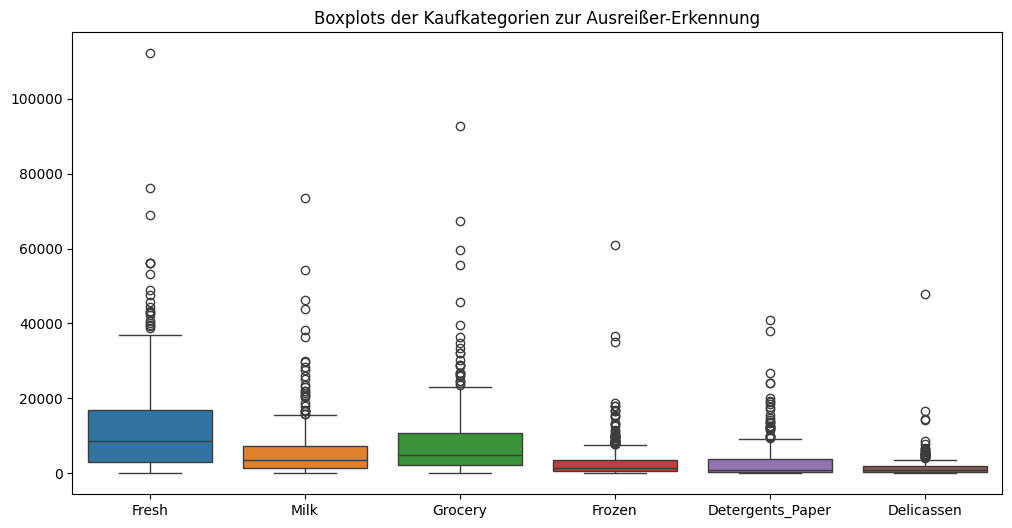

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop(['Channel','Region'], axis=1))
plt.title("Boxplots der Kaufkategorien zur Ausreißer-Erkennung")
plt.show()

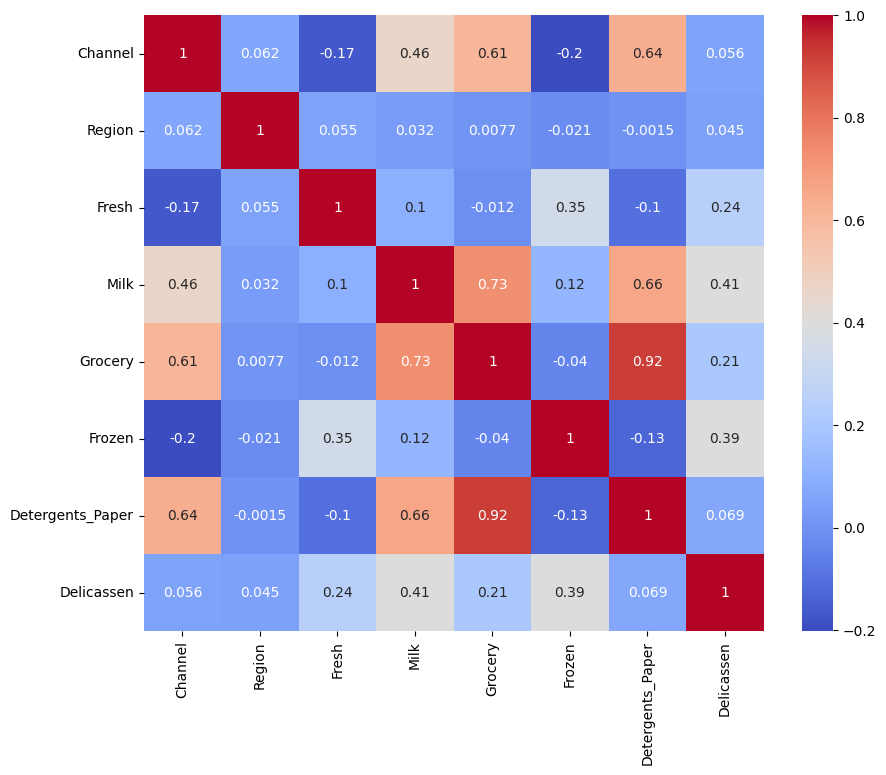

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [8]:
total_spending = df.drop(['Channel','Region'], axis=1).sum(axis=1)
top_20_count = int(0.2 * len(total_spending))
top_20_sum = total_spending.sort_values(ascending=False).head(top_20_count).sum()
total_sum = total_spending.sum()
top_20_sum / total_sum * 100

np.float64(42.90483942679298)

**Your observations here**

- ex.: Frozen, Grocery, Milk and Detergents Paper have a high...
- ...



# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

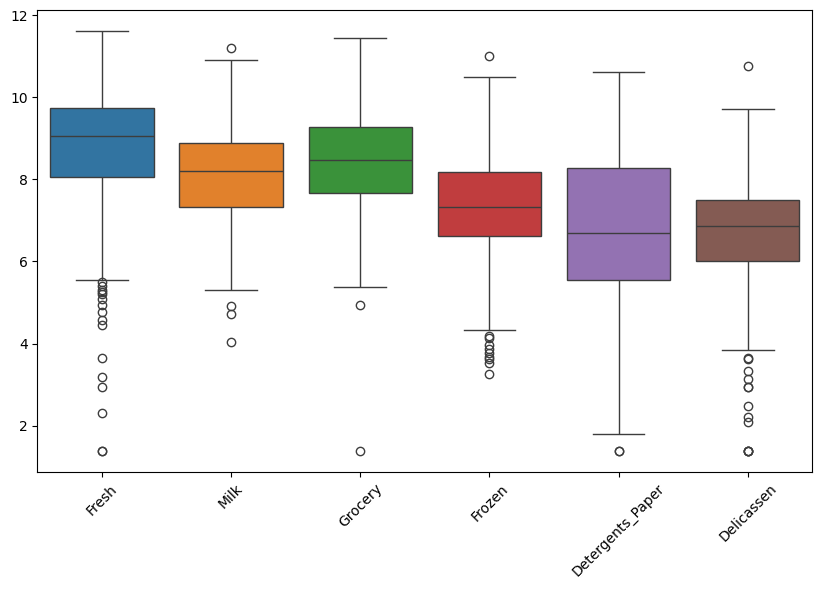

In [10]:
import numpy as np

# Remove categorical columns
features = df.drop(['Channel', 'Region'], axis=1)

# Log transformation
features_log = np.log1p(features)

features_log.head()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=features_log)
plt.xticks(rotation=45)
plt.show()

**Your comment here**

-  ...
-  ...

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [11]:
from sklearn.preprocessing import StandardScaler

features = df.drop(['Channel','Region'], axis=1)

scaler = StandardScaler()
customers_scale = scaler.fit_transform(features)

customers_scale[:5]


array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       [ 0.10011141, -0.62401993, -0.3929769 ,  0.6871443 , -0.49858822,
         0.09341105],
       [ 0.84023948, -0.05239645, -0.07935618,  0.17385884, -0.23191782,
         1.29934689]])

# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [12]:
from sklearn.cluster import KMeans

k_opt = 5
kmeans = KMeans(n_clusters=k_opt, random_state=42)
kmeans.fit(customers_scale)

df['labels'] = kmeans.labels_
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels
0,2,3,12669,9656,7561,214,2674,1338,3
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,3
4,2,3,22615,5410,7198,3915,1777,5185,1


In [13]:
kmeans.cluster_centers_

array([[-0.51381889,  0.64560212,  0.8982647 , -0.34063818,  0.9066611 ,
         0.04754206],
       [ 1.75638561, -0.12828154, -0.2192582 ,  0.85450532, -0.40434072,
         0.34325902],
       [ 0.38872897,  3.94304862,  4.02164626,  0.03578413,  4.22611641,
         0.94163573],
       [-0.22861348, -0.38400258, -0.43904531, -0.13576388, -0.39991848,
        -0.19523025],
       [ 1.80335587,  3.33298726,  0.9425185 ,  9.4098007 , -0.44640902,
         8.96415723]])

In [14]:
df.groupby('labels').mean()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
labels,,,,,,,,
0,1.906250,2.520833,5509.250000,10555.635417,16477.927083,1420.125000,7199.406250,1658.791667
1,1.135593,2.677966,34188.627119,4850.576271,5870.000000,7215.559322,955.847458,2491.796610
2,2.000000,2.545455,16911.090909,34864.363636,46126.181818,3245.454545,23008.090909,4177.363636
3,1.132353,2.522059,9112.235294,2965.404412,3783.702206,2413.591912,976.908088,974.926471
4,1.000000,2.500000,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


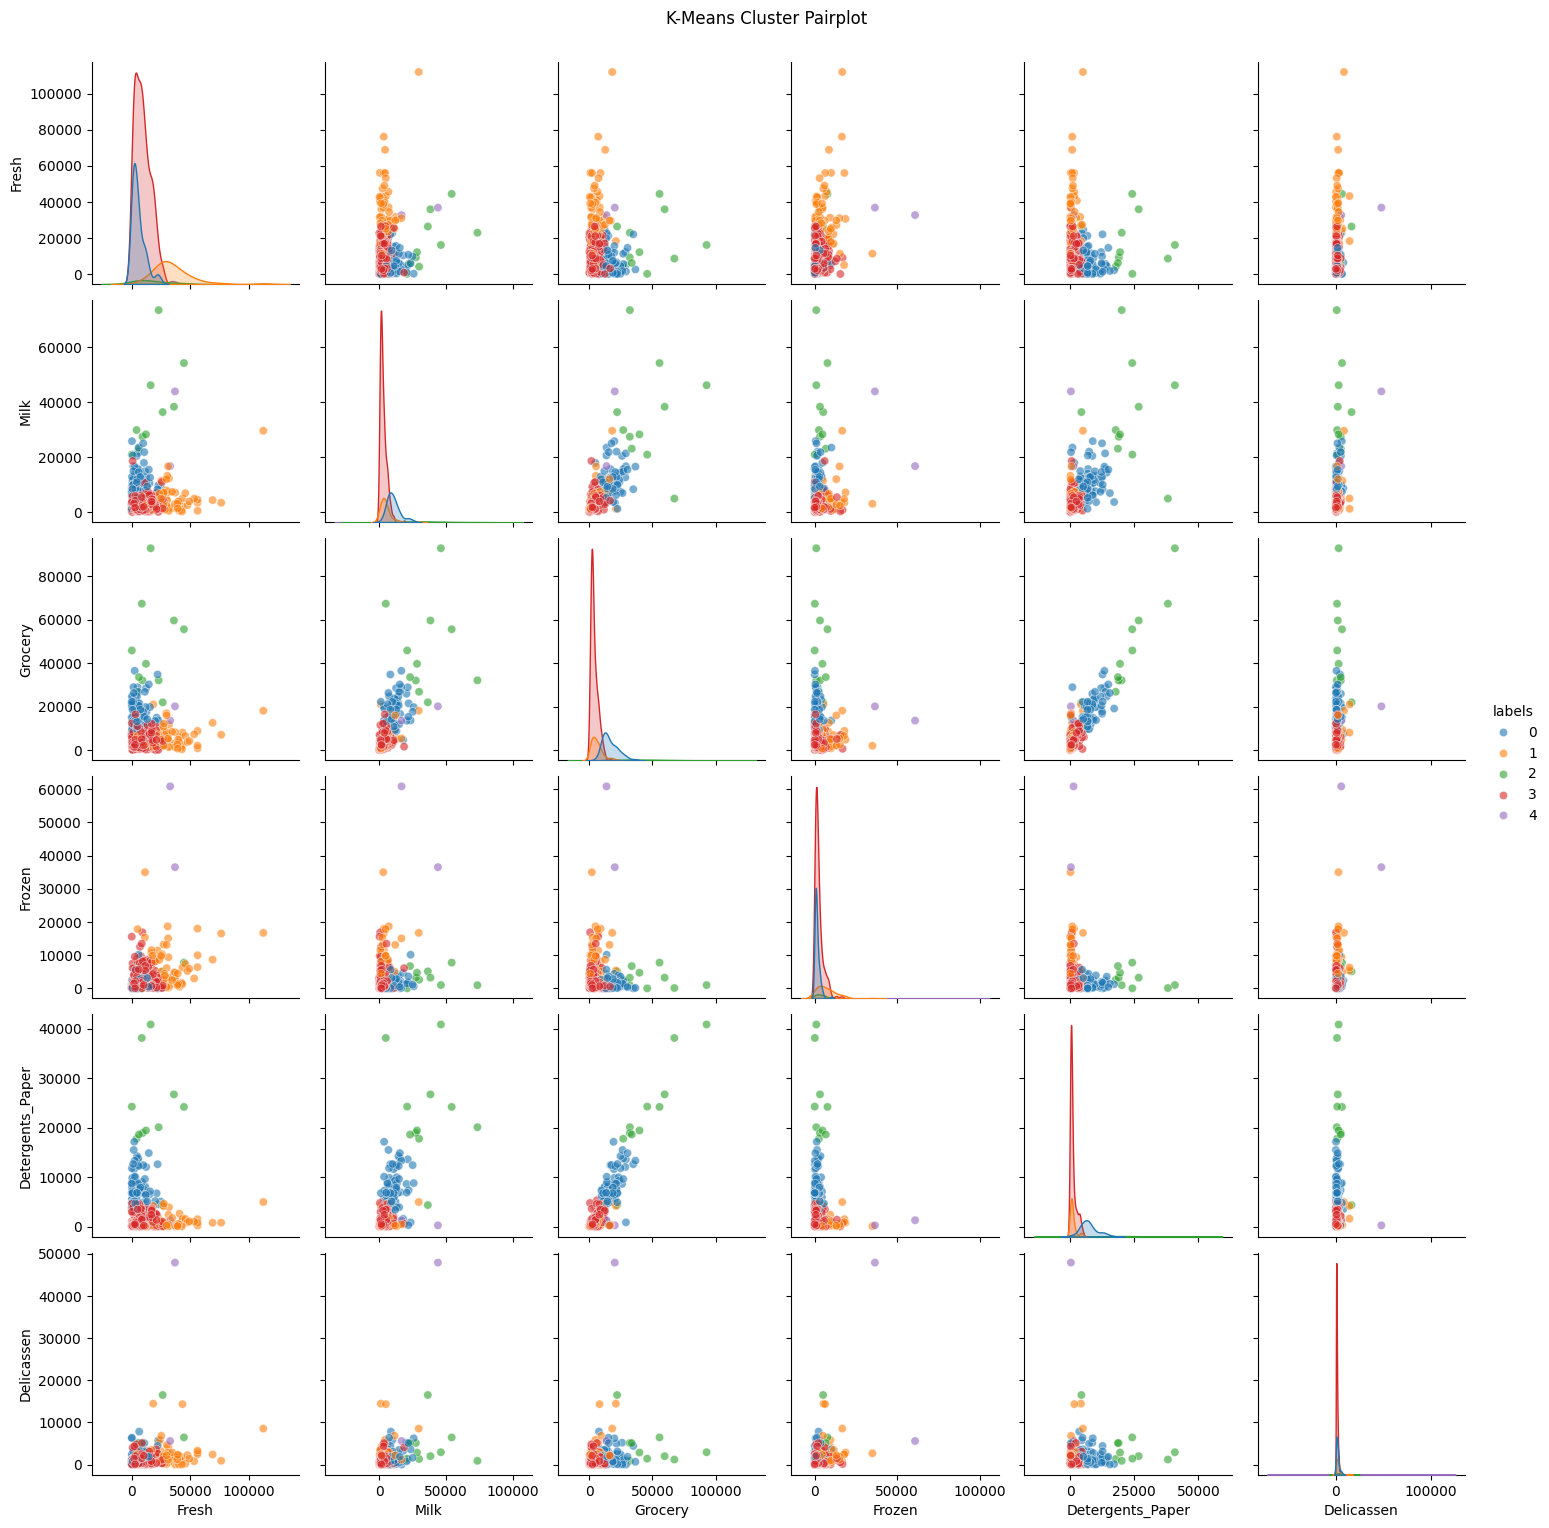

In [15]:
import seaborn as sns
import pandas as pd

# Füge die Clusterlabels in ein neues DataFrame mit ausgewählten Features
features_for_plot = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
plot_df = df[features_for_plot + ['labels']]

sns.pairplot(plot_df, hue='labels', palette='tab10', diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('K-Means Cluster Pairplot', y=1.02)
plt.show()

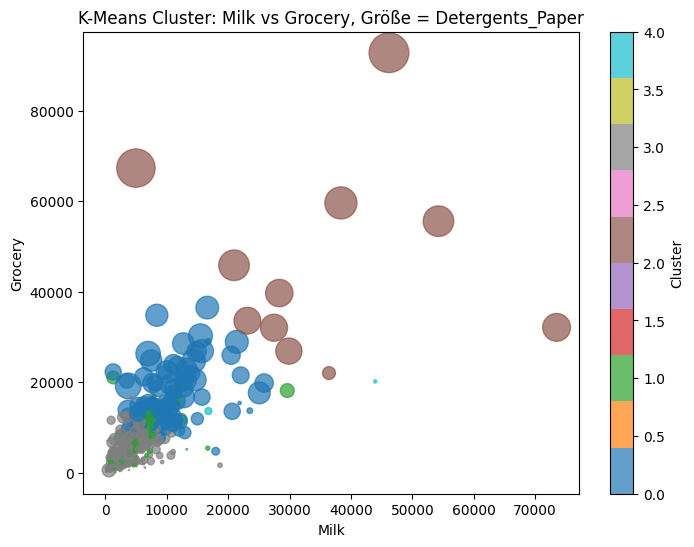

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['Milk'], df['Grocery'], c=df['labels'], cmap='tab10', s=df['Detergents_Paper']/50, alpha=0.7)
plt.xlabel('Milk')
plt.ylabel('Grocery')
plt.title('K-Means Cluster: Milk vs Grocery, Größe = Detergents_Paper')
plt.colorbar(label='Cluster')
plt.show()

### Looking to the elbow we can choose 2 like the correct number of clusters

In [17]:
kmeans_2 = KMeans(n_clusters=2).fit(customers_scale)

labels = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

In [18]:
clean_customers = df.copy()
clean_customers['Label'] = clusters
clean_customers.head()
clean_customers['Label'] = clusters

Count the values in `labels`.

In [19]:
clean_customers['Label'].value_counts()

,count
Label,
0,389
1,51


# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [21]:
from sklearn.cluster import DBSCAN

# Create DBSCAN model
dbscan = DBSCAN(eps=0.5)

# Fit model on scaled data
dbscan.fit(customers_scale)

# Assign labels to dataframe
df['labels_DBSCAN'] = dbscan.labels_

# Show first rows
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels,labels_DBSCAN
0,2,3,12669,9656,7561,214,2674,1338,3,0
1,2,3,7057,9810,9568,1762,3293,1776,0,0
2,2,3,6353,8808,7684,2405,3516,7844,0,-1
3,1,3,13265,1196,4221,6404,507,1788,3,0
4,2,3,22615,5410,7198,3915,1777,5185,1,-1


Count the values in `labels_DBSCAN`.

In [24]:
df['labels_DBSCAN'].value_counts()


,count
labels_DBSCAN,
0,261
-1,174
1,5


# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [25]:
def plot(x,y,hue):
    sns.scatterplot(x=x,
                    y=y,
                    hue=hue)
    plt.title('Detergents Paper vs Milk ')
    return plt.show();

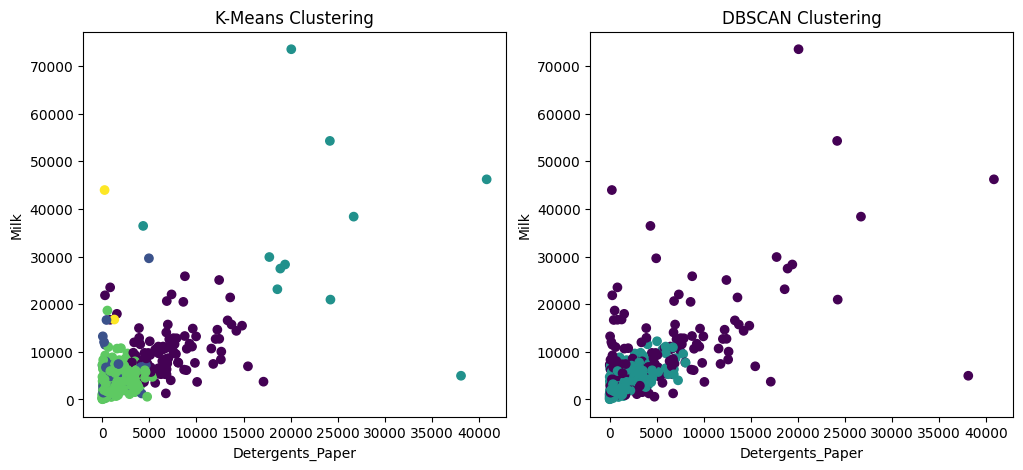

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# K-Means
plt.subplot(1,2,1)
plt.scatter(df['Detergents_Paper'], df['Milk'], c=df['labels'])
plt.xlabel('Detergents_Paper')
plt.ylabel('Milk')
plt.title('K-Means Clustering')

# DBSCAN
plt.subplot(1,2,2)
plt.scatter(df['Detergents_Paper'], df['Milk'], c=df['labels_DBSCAN'])
plt.xlabel('Detergents_Paper')
plt.ylabel('Milk')
plt.title('DBSCAN Clustering')

plt.show()

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

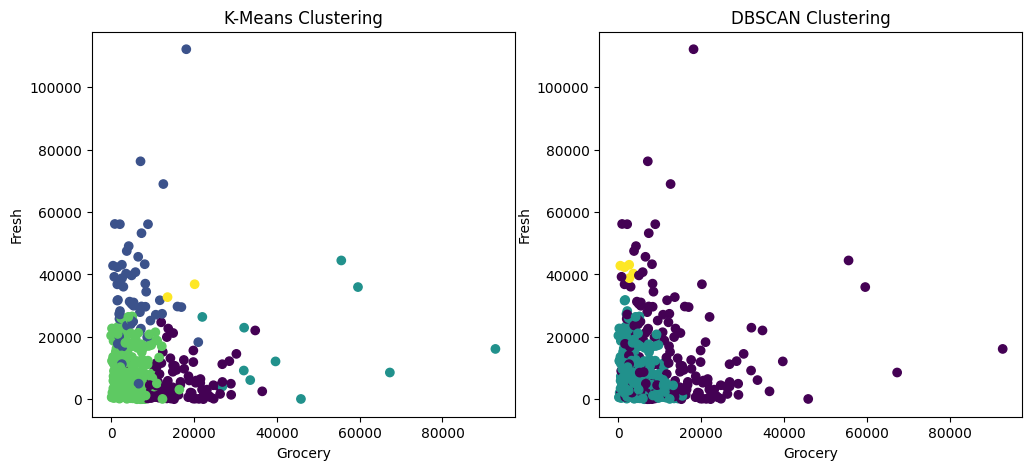

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# K-Means
plt.subplot(1,2,1)
plt.scatter(df['Grocery'], df['Fresh'], c=df['labels'])
plt.xlabel('Grocery')
plt.ylabel('Fresh')
plt.title('K-Means Clustering')

# DBSCAN
plt.subplot(1,2,2)
plt.scatter(df['Grocery'], df['Fresh'], c=df['labels_DBSCAN'])
plt.xlabel('Grocery')
plt.ylabel('Fresh')
plt.title('DBSCAN Clustering')

plt.show()

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

In [30]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen', 'labels', 'labels_DBSCAN'],
      dtype='object')

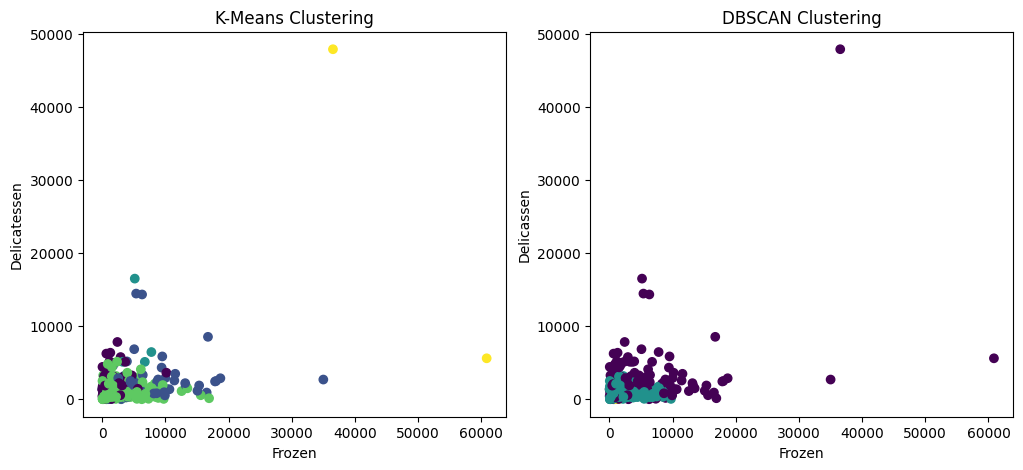

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# K-Means
plt.subplot(1,2,1)
plt.scatter(df['Frozen'], df['Delicassen'], c=df['labels'])
plt.xlabel('Frozen')
plt.ylabel('Delicatessen')
plt.title('K-Means Clustering')

# DBSCAN
plt.subplot(1,2,2)
plt.scatter(df['Frozen'], df['Delicassen'], c=df['labels_DBSCAN'])
plt.xlabel('Frozen')
plt.ylabel('Delicassen')
plt.title('DBSCAN Clustering')

plt.show()

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [32]:
print("K-Means cluster means:")
display(df.groupby('labels').mean())

print("DBSCAN cluster means:")
display(df.groupby('labels_DBSCAN').mean())

K-Means cluster means:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels_DBSCAN
labels,,,,,,,,,
0,1.906250,2.520833,5509.250000,10555.635417,16477.927083,1420.125000,7199.406250,1658.791667,-0.718750
1,1.135593,2.677966,34188.627119,4850.576271,5870.000000,7215.559322,955.847458,2491.796610,-0.745763
2,2.000000,2.545455,16911.090909,34864.363636,46126.181818,3245.454545,23008.090909,4177.363636,-1.000000
3,1.132353,2.522059,9112.235294,2965.404412,3783.702206,2413.591912,976.908088,974.926471,-0.158088
4,1.000000,2.500000,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000,-1.000000


DBSCAN cluster means:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels
labels_DBSCAN,,,,,,,,,
-1,1.522989,2.551724,15608.988506,10000.408046,13693.298851,4786.275862,5291.373563,2510.781609,1.195402
0,1.195402,2.528736,9030.398467,3077.318008,4234.061303,1963.432950,1322.134100,881.773946,2.651341
1,1.000000,3.000000,41446.600000,1421.200000,2167.600000,1276.400000,416.200000,784.800000,1.000000


Which algorithm appears to perform better?

**Your observations here**
The groupby results show the average spending behavior for each cluster. K-Means produces clearer differences between groups, indicating distinct customer segments. DBSCAN identifies some noise points and fewer clusters, which makes the segmentation less interpretable compared to K-Means.

-

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

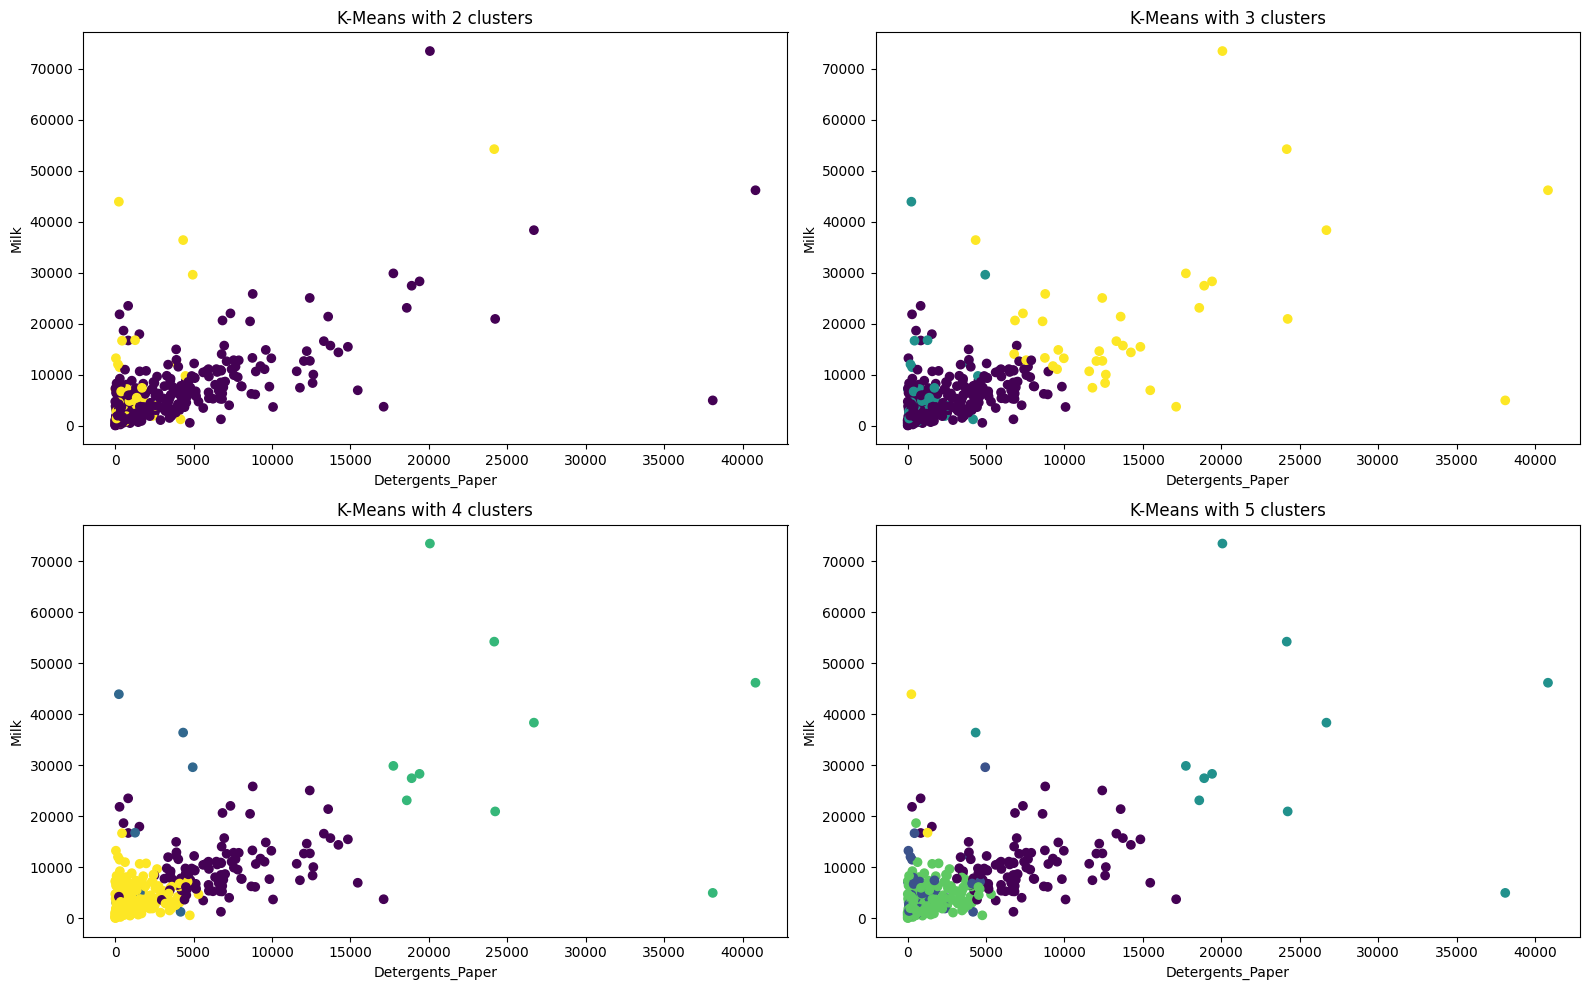

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

cluster_numbers = [2,3,4,5]

plt.figure(figsize=(16,10))

for i, k in enumerate(cluster_numbers):

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(customers_scale)

    plt.subplot(2,2,i+1)
    plt.scatter(df['Detergents_Paper'], df['Milk'], c=labels)
    plt.xlabel('Detergents_Paper')
    plt.ylabel('Milk')
    plt.title(f'K-Means with {k} clusters')

plt.tight_layout()
plt.show()

**Your comment here**

-

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

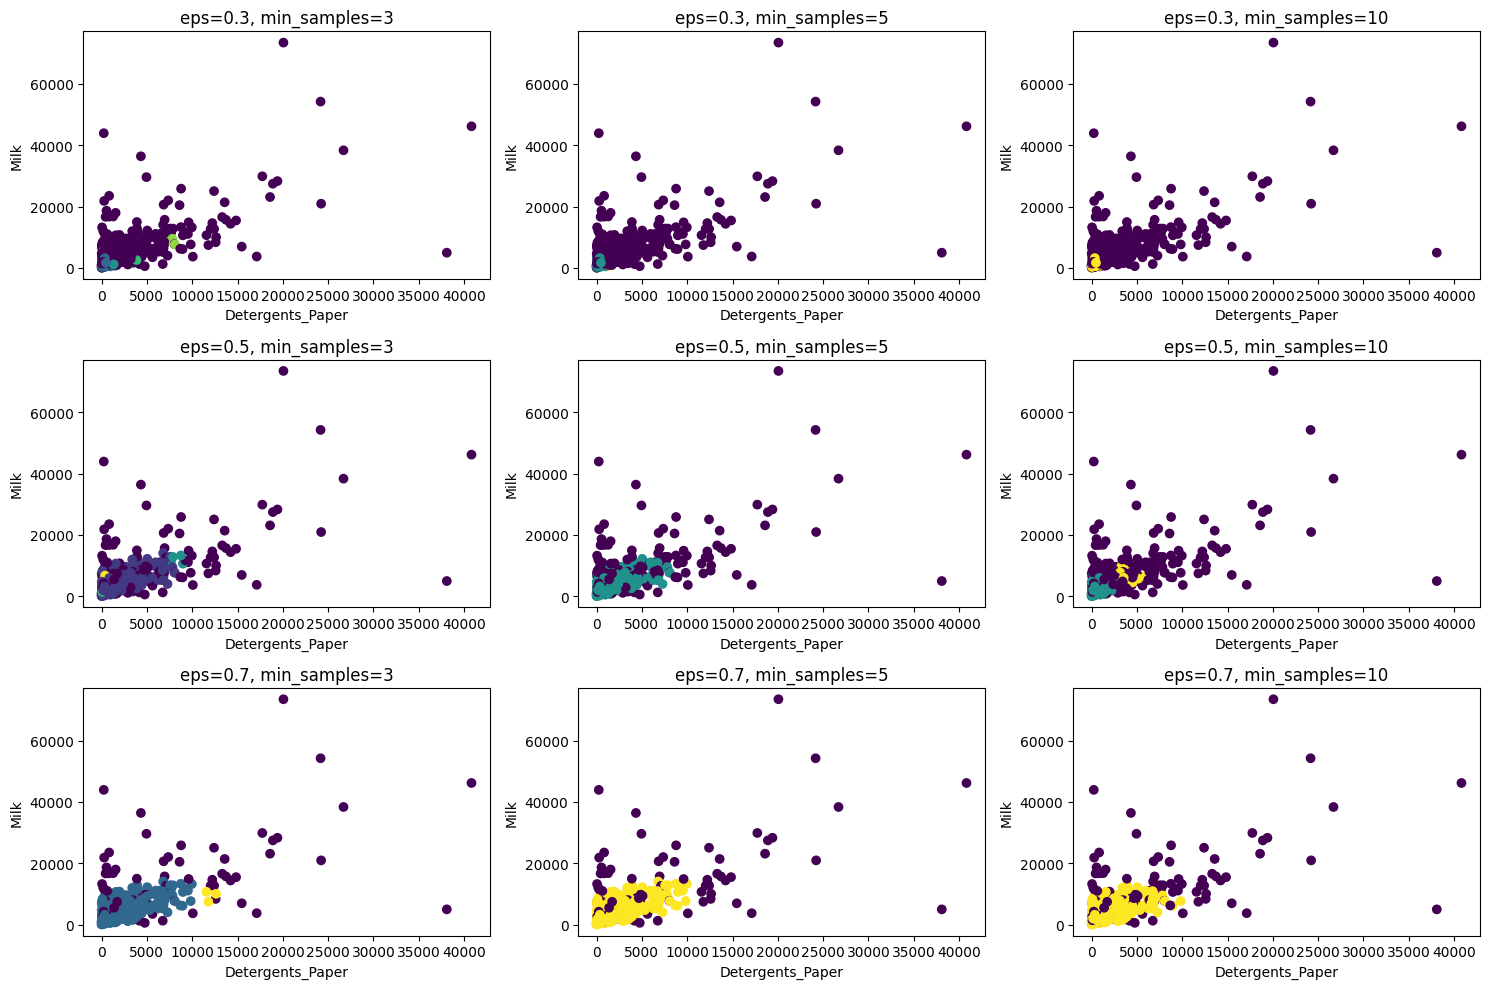

In [34]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

eps_values = [0.3, 0.5, 0.7]
min_samples_values = [3, 5, 10]

plt.figure(figsize=(15,10))

plot_number = 1

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(customers_scale)

        plt.subplot(3,3,plot_number)
        plt.scatter(df['Detergents_Paper'], df['Milk'], c=labels)
        plt.title(f"eps={eps}, min_samples={min_samples}")
        plt.xlabel("Detergents_Paper")
        plt.ylabel("Milk")

        plot_number += 1

plt.tight_layout()
plt.show()

**Your comment here**
Changing the parameters eps and min_samples significantly affects the clustering results. Smaller values of eps result in many points being labeled as noise, while larger values create larger and less distinct clusters. Increasing min_samples also increases the number of points classified as noise. Overall, DBSCAN is highly sensitive to these parameters, and selecting appropriate values is important for meaningful clustering.

-